In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print("Libraries imported successfully.")

c:\Users\rodra\devops-lab1\CSE636\project\forecasting\venv-week4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


In [2]:
# Load the generated dataset

df = pd.read_csv("cpu_metrics.csv", parse_dates=["timestamp"])

print("Dataset shape:", df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (4032, 2)

First five rows:


,timestamp,cpu_utilization
0,2025-10-01 00:00:00,11.6
1,2025-10-01 00:05:00,11.5
2,2025-10-01 00:10:00,11.7
3,2025-10-01 00:15:00,14.1
4,2025-10-01 00:20:00,11.6



Summary statistics:


,timestamp,cpu_utilization
count,4032,4032.000000
mean,2025-10-07 23:57:30,35.185640
min,2025-10-01 00:00:00,6.300000
25%,2025-10-04 11:58:45,23.175000
50%,2025-10-07 23:57:30,34.800000
75%,2025-10-11 11:56:15,47.300000
max,2025-10-14 23:55:00,93.100000
std,NaN,13.896931



Missing values:


timestamp          0
cpu_utilization    0
dtype: int64

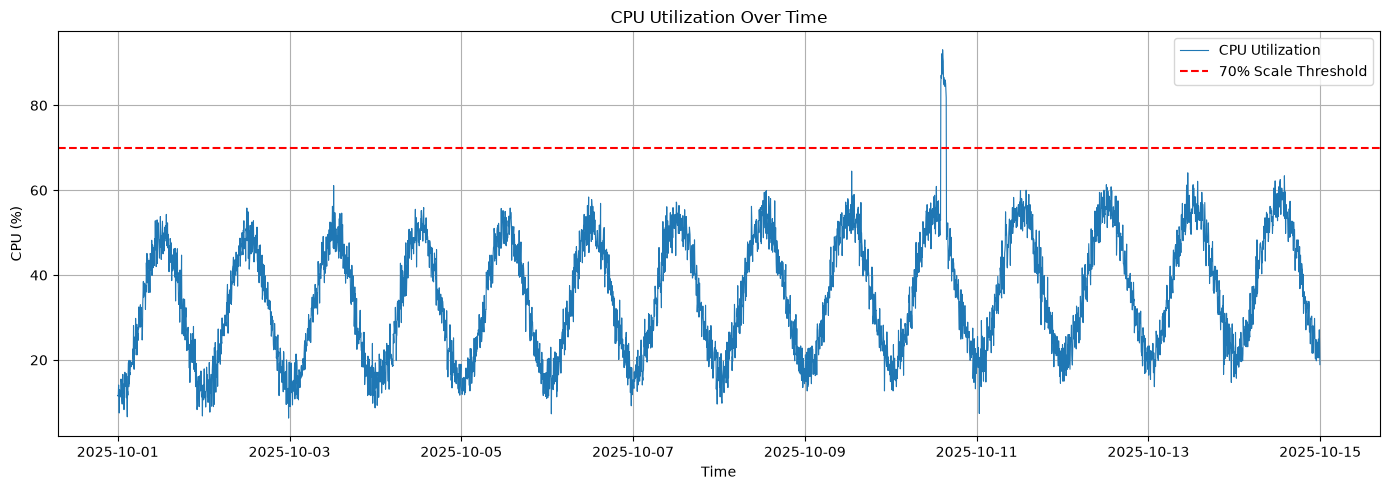

Saved metrics_overview.png


In [3]:
# CPU utilization overview

plt.figure(figsize=(14,5))

plt.plot(
    df["timestamp"],
    df["cpu_utilization"],
    linewidth=0.8,
    label="CPU Utilization"
)

plt.axhline(
    70,
    color="red",
    linestyle="--",
    label="70% Scale Threshold"
)

plt.title("CPU Utilization Over Time")
plt.xlabel("Time")
plt.ylabel("CPU (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("metrics_overview.png", dpi=120)

plt.show()

print("Saved metrics_overview.png")

In [4]:
# Prepare the data for Prophet

cpu_df = df.rename(
    columns={
        "timestamp": "ds",
        "cpu_utilization": "y"
    }
)

# Train Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    interval_width=0.80
)

model.fit(cpu_df)

# Forecast the next hour
future = model.make_future_dataframe(
    periods=12,
    freq="5min"
)

forecast = model.predict(future)

print("Forecast generated successfully.")

22:21:52 - cmdstanpy - INFO - Chain [1] start processing
22:21:53 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated successfully.


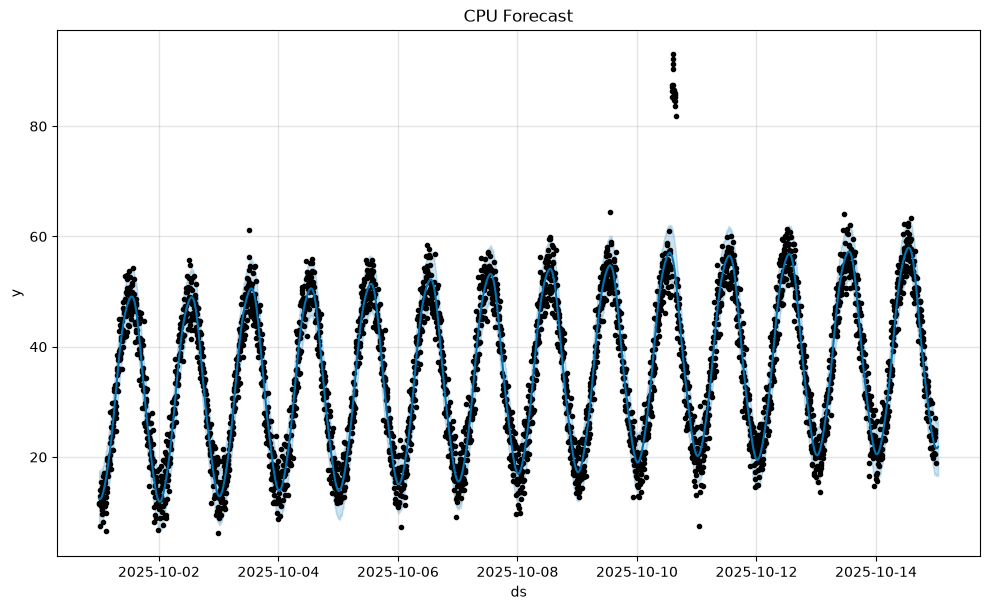

Saved cpu_forecast.png


In [5]:
# Save the Prophet forecast figure

fig1 = model.plot(forecast)

plt.title("CPU Forecast")

plt.savefig(
    "cpu_forecast.png",
    dpi=120
)

plt.show()

print("Saved cpu_forecast.png")

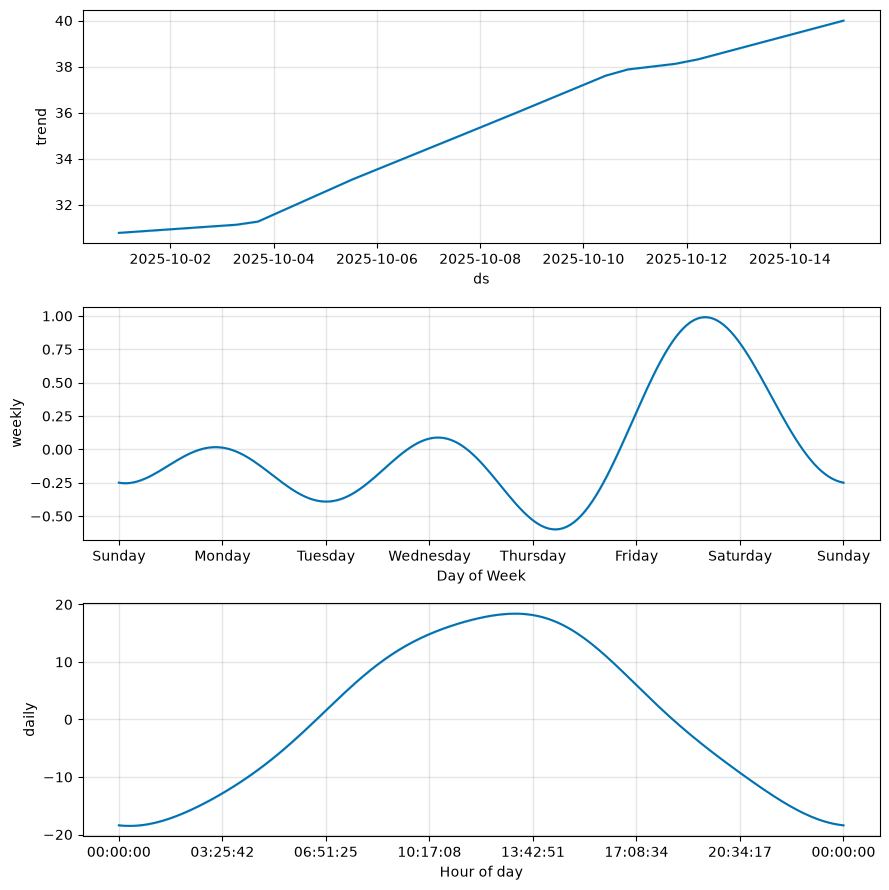

Saved cpu_forecast_components.png


In [6]:
# Save Prophet components

fig2 = model.plot_components(forecast)

plt.savefig(
    "cpu_forecast_components.png",
    dpi=120
)

plt.show()

print("Saved cpu_forecast_components.png")

Training rows: 3743
Testing rows : 289


C:\Users\rodra\AppData\Local\Temp\ipykernel_26300\1333708152.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  split_time = cpu_df["ds"].max() - pd.Timedelta(hours=24)
22:21:56 - cmdstanpy - INFO - Chain [1] start processing
22:21:56 - cmdstanpy - INFO - Chain [1] done processing



MAE : 2.57% CPU
MAPE: 7.1%


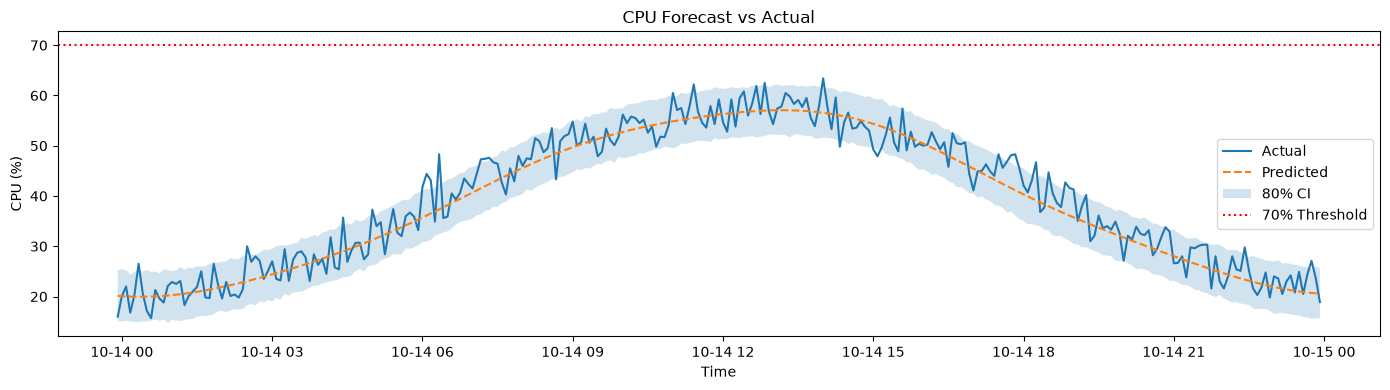

Saved cpu_eval.png


In [7]:
# -------------------------------
# Evaluate the forecast
# -------------------------------

# Use the last 24 hours as the test set

split_time = cpu_df["ds"].max() - pd.Timedelta(hours=24)

train = cpu_df[cpu_df["ds"] < split_time].copy()
test = cpu_df[cpu_df["ds"] >= split_time].copy()

print("Training rows:", len(train))
print("Testing rows :", len(test))

# Train another Prophet model using only the training data

eval_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    interval_width=0.80
)

eval_model.fit(train)

future = eval_model.make_future_dataframe(
    periods=len(test),
    freq="5min"
)

forecast_eval = eval_model.predict(future)

test_forecast = forecast_eval[
    forecast_eval["ds"].isin(test["ds"])
]

actual = test["y"].values
predicted = test_forecast["yhat"].values

mae = mean_absolute_error(actual, predicted)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print(f"\nMAE : {mae:.2f}% CPU")
print(f"MAPE: {mape:.1f}%")

# Plot actual vs predicted

plt.figure(figsize=(14,4))

plt.plot(
    test["ds"],
    actual,
    label="Actual"
)

plt.plot(
    test_forecast["ds"],
    predicted,
    "--",
    label="Predicted"
)

plt.fill_between(
    test_forecast["ds"],
    test_forecast["yhat_lower"],
    test_forecast["yhat_upper"],
    alpha=0.2,
    label="80% CI"
)

plt.axhline(
    70,
    color="red",
    linestyle=":",
    label="70% Threshold"
)

plt.title("CPU Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("CPU (%)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "cpu_eval.png",
    dpi=120
)

plt.show()

print("Saved cpu_eval.png")

In [8]:
# Autoscaling recommendation using the next 30-minute forecast

import math

current_replicas = 5
target_cpu = 60
horizon_minutes = 30
periods = horizon_minutes // 5

# Use the upper 80% confidence bound for a conservative estimate
upcoming = forecast.tail(periods)
max_predicted_cpu = upcoming["yhat_upper"].max()

recommended_replicas = math.ceil(
    current_replicas * max_predicted_cpu / target_cpu
)

# Apply reasonable minimum and maximum limits
recommended_replicas = max(2, min(50, recommended_replicas))

print("--- Autoscaling Recommendation ---")
print(f"Current replicas: {current_replicas}")
print(f"Maximum predicted CPU in next 30 minutes: {max_predicted_cpu:.1f}%")
print(f"Target CPU per replica: {target_cpu}%")
print(f"Recommended replicas: {recommended_replicas}")

if recommended_replicas > current_replicas:
    print(
        f"DECISION: Scale UP by "
        f"{recommended_replicas - current_replicas} replica(s)"
    )
elif recommended_replicas < current_replicas:
    print(
        f"DECISION: Scale DOWN by "
        f"{current_replicas - recommended_replicas} replica(s)"
    )
else:
    print("DECISION: No change")

--- Autoscaling Recommendation ---
Current replicas: 5
Maximum predicted CPU in next 30 minutes: 26.8%
Target CPU per replica: 60%
Recommended replicas: 3
DECISION: Scale DOWN by 2 replica(s)
